In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [18]:
df = pd.read_csv('data/forestfires.csv')[:round(len(df)*0.9)]

In [19]:
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


# Explications des différents parametres du jeu données

## Variables du jeu de données forestfires.csv

- **X** : Coordonnée spatiale horizontale de la zone (position dans la grille).
- **Y** : Coordonnée spatiale verticale de la zone (position dans la grille).

- **month** : Mois de l'observation (`jan` à `dec`).
- **day** : Jour de la semaine (`mon` à `sun`).

- **FFMC** (*Fine Fuel Moisture Code*) : Indice d'humidité des combustibles fins en surface (feuilles, petites brindilles).
  Plus la valeur est élevée, plus ces combustibles sont secs et faciles à enflammer.

- **DMC** (*Duff Moisture Code*) : Indice de sécheresse de la couche organique intermédiaire.
  Plus la valeur est élevée, plus cette couche est sèche.

- **DC** (*Drought Code*) : Indice de sécheresse profonde et de long terme.
  Une valeur élevée indique des conditions de sécheresse durable.

- **ISI** (*Initial Spread Index*) : Potentiel de vitesse de propagation initiale d'un feu.
  Plus il est élevé, plus le feu peut se propager rapidement.

- **temp** : Température de l'air (°C).
- **RH** : Humidité relative de l'air (%).
- **wind** : Vitesse du vent (souvent en km/h dans ce dataset).
- **rain** : Précipitations (mm).

- **area** : Surface brûlée (en hectares).
  C'est généralement la variable cible à prédire dans les modèles.

## Statistiques descriptives (quantitatives et qualitatives)


In [20]:
# Séparation des variables par type
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude=['number']).columns

print('Variables quantitatives :', list(num_cols))
print('Variables qualitatives :', list(cat_cols))

# Statistiques descriptives des variables quantitatives
stats_quant = df[num_cols].describe().T
stats_quant['median'] = df[num_cols].median()
stats_quant['variance'] = df[num_cols].var()
stats_quant['missing'] = df[num_cols].isna().sum()

# Réorganisation des colonnes pour la lisibilité
stats_quant = stats_quant[['count', 'mean', 'median', 'std', 'variance', 'min', '25%', '50%', '75%', 'max', 'missing']]
print('\n=== Statistiques descriptives : variables quantitatives ===')
display(stats_quant)

# Statistiques descriptives des variables qualitatives
if len(cat_cols) > 0:
    print('\n=== Statistiques descriptives : variables qualitatives ===')
    qual_summary = pd.DataFrame({
        'count': df[cat_cols].count(),
        'n_unique': df[cat_cols].nunique(),
        'mode': df[cat_cols].mode().iloc[0],
        'freq_mode': df[cat_cols].apply(lambda s: s.value_counts(dropna=False).iloc[0]),
        'missing': df[cat_cols].isna().sum()
    })
    display(qual_summary)

    print('\n=== Fréquences (effectifs) par variable qualitative ===')
    for col in cat_cols:
        print(f'\n--- {col} ---')
        display(df[col].value_counts(dropna=False).to_frame(name='effectif'))

    print('\n=== Fréquences relatives (%) par variable qualitative ===')
    for col in cat_cols:
        print(f'\n--- {col} ---')
        display((df[col].value_counts(dropna=False, normalize=True) * 100).round(2).to_frame(name='pourcentage'))
else:
    print('Aucune variable qualitative détectée.')

Variables quantitatives : ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']
Variables qualitatives : ['month', 'day']

=== Statistiques descriptives : variables quantitatives ===


,count,mean,median,std,variance,min,25%,50%,75%,max,missing
X,418.0,4.736842,4.00,2.262748,5.120030,1.0,3.000,4.00,7.0000,9.00,0
Y,418.0,4.301435,4.00,1.231111,1.515633,2.0,4.000,4.00,5.0000,9.00,0
FFMC,418.0,90.412919,91.60,5.751169,33.075948,18.7,90.200,91.60,92.5000,96.00,0
DMC,418.0,100.607416,102.30,55.317565,3060.032966,1.1,52.200,102.30,131.7000,291.30,0
DC,418.0,542.539234,662.75,250.112029,62556.026946,7.9,431.425,662.75,709.9000,860.60,0
ISI,418.0,8.768182,8.40,4.465940,19.944621,0.0,6.300,8.40,10.4000,56.10,0
temp,418.0,18.210526,18.90,5.376972,28.911831,2.2,15.250,18.90,21.8000,30.20,0
RH,418.0,43.344498,41.00,15.829911,250.586073,15.0,32.000,41.00,51.0000,100.00,0
wind,418.0,3.943301,3.60,1.787853,3.196418,0.4,2.700,3.60,4.9000,9.40,0
rain,418.0,0.003349,0.00,0.050781,0.002579,0.0,0.000,0.00,0.0000,1.00,0



=== Statistiques descriptives : variables qualitatives ===


,count,n_unique,mode,freq_mode,missing
month,418,11,sep,165,0
day,418,7,sun,75,0



=== Fréquences (effectifs) par variable qualitative ===

--- month ---


...

,effectif
day,
sun,75
fri,71
sat,70
mon,62
tue,52
thu,45
wed,43



=== Fréquences relatives (%) par variable qualitative ===

--- month ---


,pourcentage
month,
sep,39.47
aug,28.23
mar,11.96
jul,5.26
feb,4.07
oct,3.59
jun,3.11
dec,2.15
apr,1.44



--- day ---


,pourcentage
day,
sun,17.94
fri,16.99
sat,16.75
mon,14.83
tue,12.44
thu,10.77
wed,10.29


# Ecart type

### Formule
$$\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}$$

In [21]:
df_num = df[num_cols]

# Ecart type
df_num.std()

X         2.262748
Y         1.231111
FFMC      5.751169
DMC      55.317565
DC      250.112029
ISI       4.465940
temp      5.376972
RH       15.829911
wind      1.787853
rain      0.050781
area     68.608903
dtype: float64

# Choix de la variable la plus importante pour la prédiction de l'aire brûlée

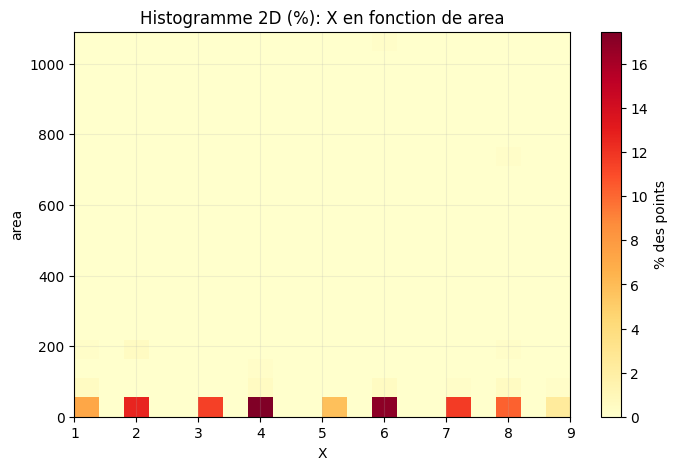

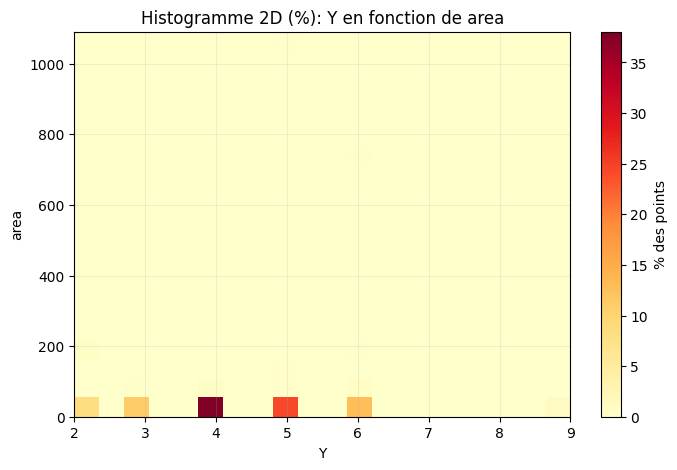

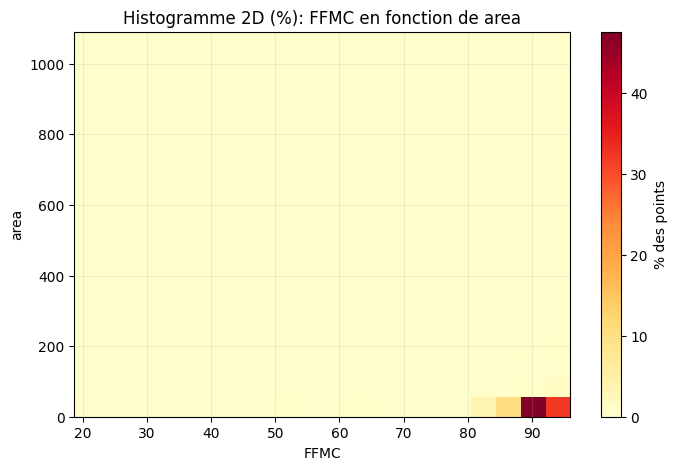

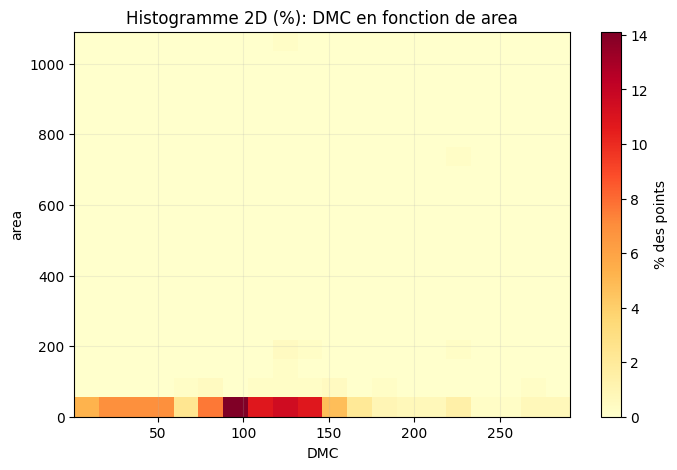

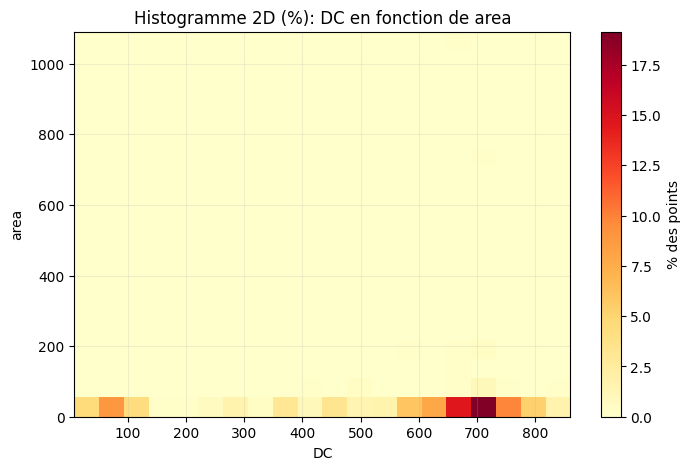

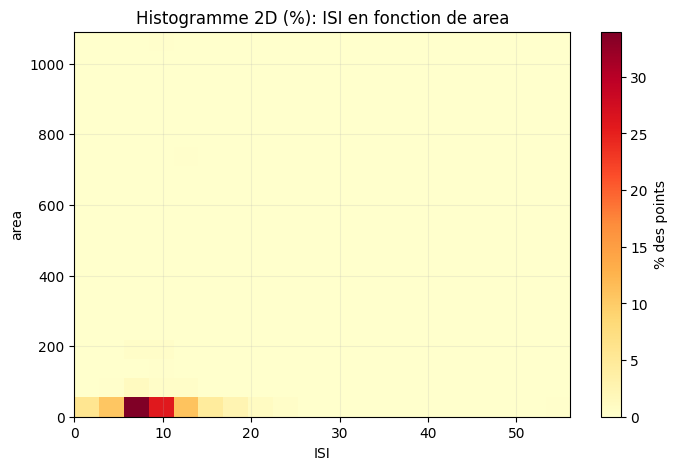

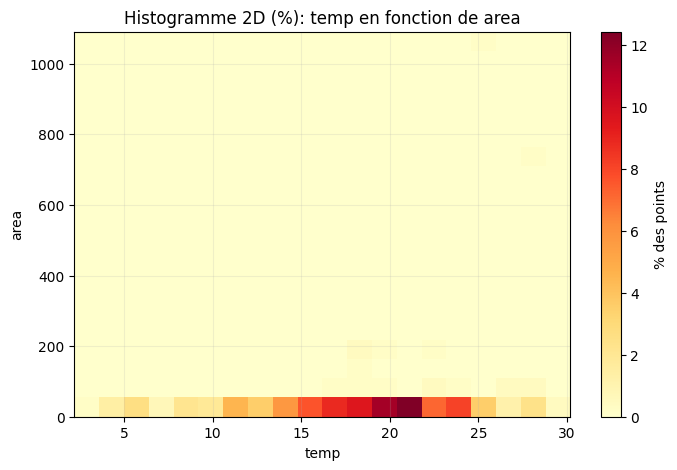

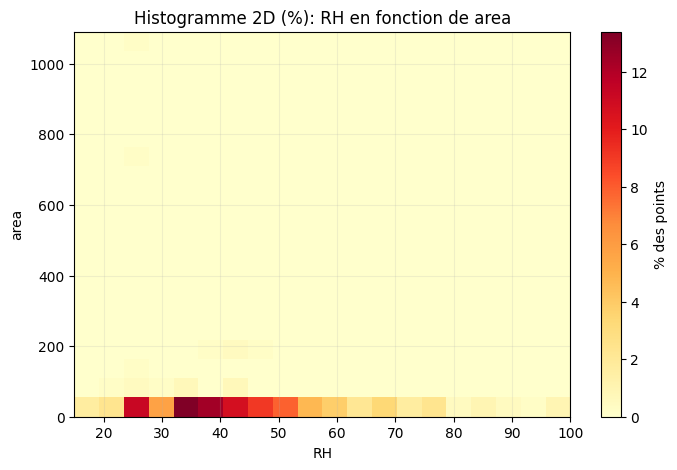

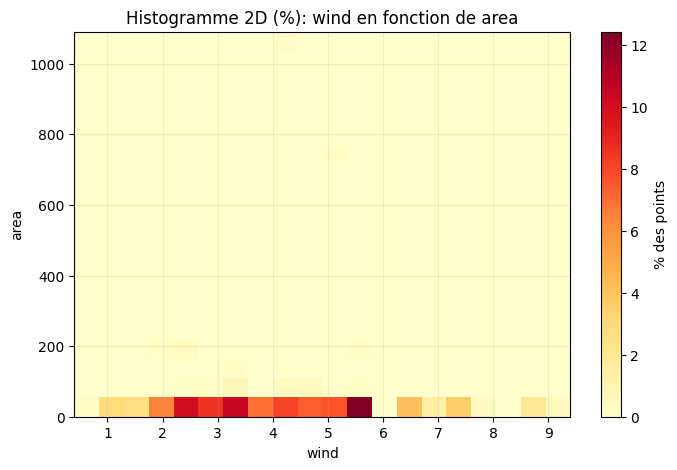

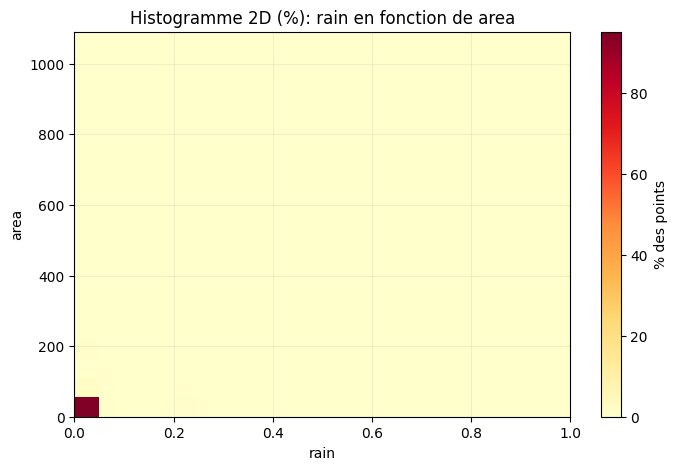

In [25]:
# Histogrammes 2D en pourcentage de toutes les variables quantitatives vs surface brûlée
target = 'area'
bins_x = 20
bins_y = 20

for variable in num_cols:
    if variable == target:
        continue

    # On garde uniquement les lignes valides pour les deux colonnes
    tmp = df[[variable, target]].dropna()
    if len(tmp) == 0:
        continue

    x = tmp[variable]
    y = tmp[target]

    # Chaque point vaut 100 / N pour afficher un pourcentage par case
    weights = np.ones(len(tmp)) * (100 / len(tmp))

    plt.figure(figsize=(8, 5))
    h = plt.hist2d(
        x, y,
        bins=[bins_x, bins_y],
        weights=weights,
        cmap='YlOrRd'
    )

    cbar = plt.colorbar(h[3])
    cbar.set_label('% des points')

    plt.title(f'Histogramme 2D (%): {variable} en fonction de {target}')
    plt.xlabel(variable)
    plt.ylabel(target)
    plt.grid(alpha=0.2)
    plt.show()


# 